# TrashTrack — EDA (TACO + UAVVaste)
MSDS 498 Capstone · Group 4.

This notebook profiles annotations across litter-detection sources to inform modeling choices. The two questions that drive the whole detector design:
1. **How imbalanced are the classes?** (affects loss/sampling)
2. **How small are the objects?** (affects input resolution / tiling)

Currently covers **TACO** (ground-level) and **UAVVaste** (aerial), profiled and compared side by side. **RoLID-11K** (dashcam) is next, pending manual download from its Google Drive (no direct GitHub file access) — see Section 7 for what to check once it's loaded.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Colab-safe: pulls straight from the official TACO repo, no upload/Drive mount needed
!wget -q https://raw.githubusercontent.com/pedropro/TACO/master/data/annotations.json -O taco_annotations.json
ANN_PATH = 'taco_annotations.json'  # swap for UAVVaste / RoLID-11K
d = json.load(open(ANN_PATH))
images = pd.DataFrame(d['images'])
anns   = pd.DataFrame(d['annotations'])
cats   = pd.DataFrame(d['categories'])
print(len(images), 'images |', len(anns), 'annotations |', len(cats), 'categories')

1500 images | 4784 annotations | 60 categories


## 1. Enrich annotations with class, supercategory, and size features

In [2]:
cat_map = dict(zip(cats.id, cats.name)); super_map = dict(zip(cats.id, cats.supercategory))
anns['cat_name'] = anns['category_id'].map(cat_map)
anns['supercat'] = anns['category_id'].map(super_map)
bb = np.array(anns['bbox'].tolist(), float)
anns['bw'], anns['bh'] = bb[:,2], bb[:,3]
anns['bbox_area'] = anns['bw']*anns['bh']
dims = images.set_index('id')[['width','height']]
anns = anns.join(dims, on='image_id')
anns['rel_area_pct'] = 100*anns['bbox_area']/(anns['width']*anns['height'])
def bucket(a):
    return 'small' if a<32**2 else ('medium' if a<96**2 else 'large')
anns['size_bucket'] = anns['bbox_area'].apply(bucket)
anns[['cat_name','supercat','bbox_area','rel_area_pct','size_bucket']].head()

,cat_name,supercat,bbox_area,rel_area_pct,size_bucket
0,Glass bottle,Bottle,590934.0,18.763902,large
1,Meal carton,Carton,2170651.0,68.924588,large
2,Other carton,Carton,676032.0,21.466015,large
3,Clear plastic bottle,Bottle,187000.0,5.937803,large
4,Plastic bottle cap,Bottle cap,2244.0,0.071254,medium


## 2. Class imbalance

imbalance ratio (max:min) = 667
classes with <20 instances: 25 of 59
top-5 share: 45.8 %


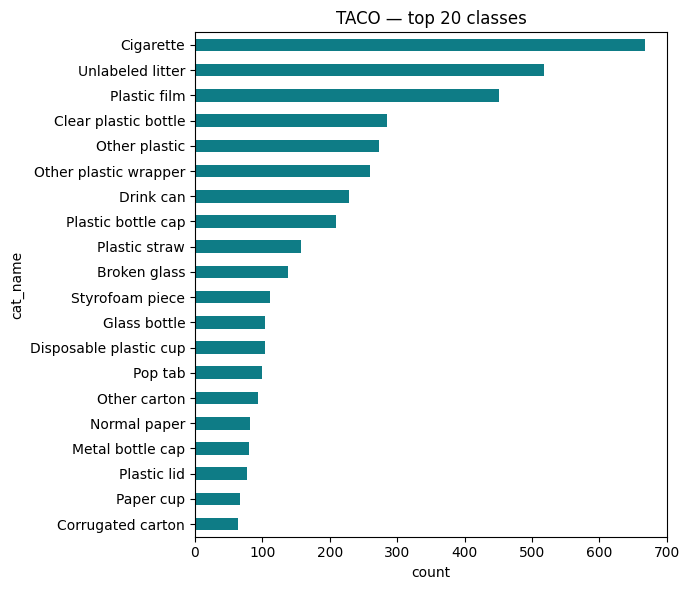

In [3]:
cc = anns['cat_name'].value_counts()
print('imbalance ratio (max:min) =', round(cc.max()/cc.min()))
print('classes with <20 instances:', int((cc<20).sum()), 'of', len(cc))
print('top-5 share:', round(cc.head(5).sum()/cc.sum()*100,1), '%')
cc.head(20)[::-1].plot.barh(figsize=(7,6), color='#0e7c86')
plt.title('TACO — top 20 classes'); plt.xlabel('count'); plt.tight_layout(); plt.show()

## 3. Small-object analysis
The single most important modeling fact for this project.

median bbox as % of image: 0.35 %
share < 1% of image  : 67.2 %
size_bucket
large     3095
medium    1306
small      383
Name: count, dtype: int64


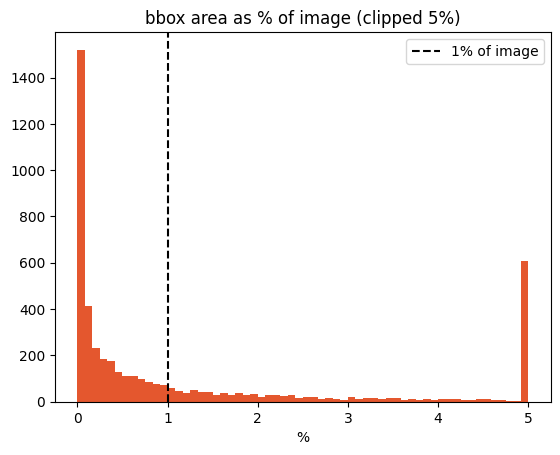

In [4]:
print('median bbox as % of image:', round(anns.rel_area_pct.median(),3), '%')
print('share < 1% of image  :', round((anns.rel_area_pct<1).mean()*100,1), '%')
print(anns.size_bucket.value_counts())
plt.hist(np.clip(anns.rel_area_pct,0,5), bins=60, color='#e4572e')
plt.axvline(1, ls='--', color='k', label='1% of image'); plt.legend()
plt.title('bbox area as % of image (clipped 5%)'); plt.xlabel('%'); plt.show()

## 4. Objects per image & resolution

objects/image  mean 3.19  median 2  max 90
image width  median 2448 | height median 3264


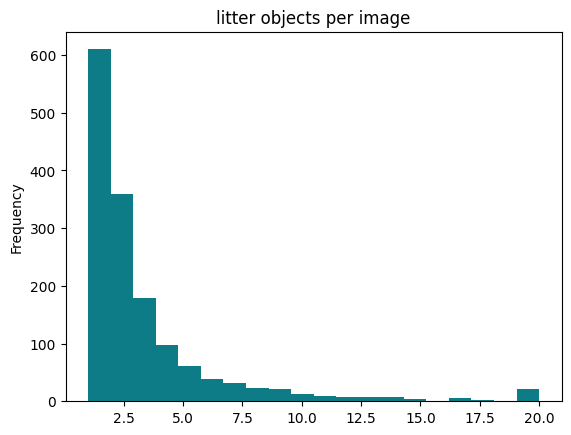

In [5]:
per = anns.groupby('image_id').size()
print('objects/image  mean %.2f  median %d  max %d' % (per.mean(), per.median(), per.max()))
print('image width  median', int(images.width.median()), '| height median', int(images.height.median()))
per.clip(upper=20).plot.hist(bins=20, color='#0e7c86')
plt.title('litter objects per image'); plt.show()

## 5. Takeaways for modeling
- **Severe imbalance** → use focal loss / class-balanced sampling; consider collapsing 60 classes to a single `litter` class for the first fine-tune, then refine.
- **Tiny objects** (median ~0.35% of image, 67% under 1%) → train at high input resolution and/or **tile** large images; small anchors.
- **Very large source images** (median ~2448×3264) → tiling is not optional for TACO.
- Re-run this notebook on UAVVaste (aerial → even smaller objects) and RoLID-11K (dashcam → motion blur) to compare the size distributions before benchmarking.

## 6. UAVVaste — aerial domain comparison
Same EDA, second dataset. UAVVaste is 772 drone/aerial images of litter (Kraft et al., 2021), COCO-format, single `litter` class.
We reuse the exact same enrichment logic as TACO (Section 1) so the two are directly comparable — different variable names (`anns_u`, `images_u`, etc.) so both stay in memory at once.

In [6]:
# Download UAVVaste's official COCO-format annotations (annotations only — no images needed for this EDA,
# same pattern as TACO). Source: https://github.com/PUTvision/UAVVaste
!wget -q https://raw.githubusercontent.com/PUTvision/UAVVaste/main/annotations/annotations.json -O uavvaste_annotations.json

ANN_PATH_UAV = 'uavvaste_annotations.json'
d_u = json.load(open(ANN_PATH_UAV))
images_u = pd.DataFrame(d_u['images'])
anns_u   = pd.DataFrame(d_u['annotations'])
cats_u   = pd.DataFrame(d_u['categories'])
print(len(images_u), 'images |', len(anns_u), 'annotations |', len(cats_u), 'categories')
cats_u

772

 images | 3718 annotations | 1 categories


,supercategory,id,name
0,,0,rubbish


In [7]:
# Same enrichment as Section 1 — class, supercategory (fallback to name if UAVVaste has no supercategory), size features
cat_map_u = dict(zip(cats_u.id, cats_u.name))
super_map_u = dict(zip(cats_u.id, cats_u['supercategory'])) if 'supercategory' in cats_u.columns else cat_map_u
anns_u['cat_name'] = anns_u['category_id'].map(cat_map_u)
anns_u['supercat'] = anns_u['category_id'].map(super_map_u)
bb_u = np.array(anns_u['bbox'].tolist(), float)
anns_u['bw'], anns_u['bh'] = bb_u[:,2], bb_u[:,3]
anns_u['bbox_area'] = anns_u['bw']*anns_u['bh']
dims_u = images_u.set_index('id')[['width','height']]
anns_u = anns_u.join(dims_u, on='image_id')
anns_u['rel_area_pct'] = 100*anns_u['bbox_area']/(anns_u['width']*anns_u['height'])
anns_u['size_bucket'] = anns_u['bbox_area'].apply(bucket)
anns_u[['cat_name','bbox_area','rel_area_pct','size_bucket']].head()

,cat_name,bbox_area,rel_area_pct,size_bucket
0,rubbish,17816.0,0.214796,large
1,rubbish,1296.0,0.015625,medium
2,rubbish,3300.0,0.039786,medium
3,rubbish,8640.0,0.104167,medium
4,rubbish,10366.0,0.124976,large


In [8]:
# Side-by-side stats — TACO vs UAVVaste
per_u = anns_u.groupby('image_id').size()

summary = pd.DataFrame({
    'TACO':     [len(images), len(anns), len(cats), round(anns.rel_area_pct.median(),3),
                 round((anns.rel_area_pct<1).mean()*100,1), round(per.mean(),2), int(images.width.median())],
    'UAVVaste': [len(images_u), len(anns_u), len(cats_u), round(anns_u.rel_area_pct.median(),3),
                 round((anns_u.rel_area_pct<1).mean()*100,1), round(per_u.mean(),2), int(images_u.width.median())],
}, index=['images', 'annotations', 'classes', 'median bbox % of image',
          '% boxes < 1% of image', 'objects/image (mean)', 'median image width (px)'])
summary

,TACO,UAVVaste
images,1500.00,772.000
annotations,4784.00,3718.000
classes,60.00,1.000
median bbox % of image,0.35,0.072
% boxes < 1% of image,67.20,99.200
objects/image (mean),3.19,4.820
median image width (px),2448.00,3840.000


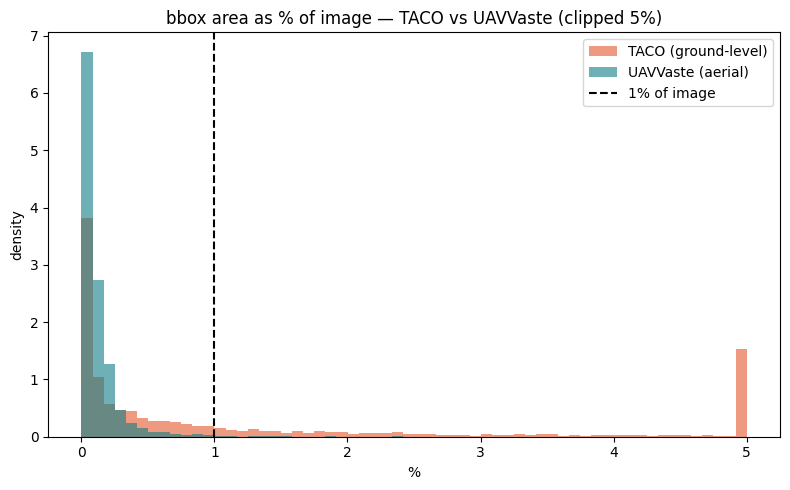

In [9]:
# Overlaid size distributions — the key comparison for tiling/resolution decisions
plt.figure(figsize=(8,5))
plt.hist(np.clip(anns.rel_area_pct,0,5), bins=60, alpha=0.6, color='#e4572e', density=True, label='TACO (ground-level)')
plt.hist(np.clip(anns_u.rel_area_pct,0,5), bins=60, alpha=0.6, color='#0e7c86', density=True, label='UAVVaste (aerial)')
plt.axvline(1, ls='--', color='k', label='1% of image')
plt.title('bbox area as % of image — TACO vs UAVVaste (clipped 5%)')
plt.xlabel('%'); plt.ylabel('density'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Takeaways — TACO vs UAVVaste
- Fill in after running: compare median `rel_area_pct` and `% boxes < 1%` from the summary table above.
- Expectation going in (per the UAVVaste paper): aerial objects should be **smaller and more uniform in size** than TACO's ground-level photos, reinforcing the tiling/high-resolution-input decision rather than changing it.
- UAVVaste is single-class (`litter`) — it won't inform the class-imbalance strategy, only the size/resolution one. Class-level modeling decisions still rest on TACO (and later RoLID-11K).
- Next: repeat this same pattern for RoLID-11K once its annotation format is confirmed from its repo, then move to the merge script (unified taxonomy + source-tagged, group-aware split).